In [20]:
"""
ML Pipeline for MRoS multiclass precipitation-phase prediction using raw MRoS labels
and leakage-safe LOOCV MRoS probability predictors.

This refactored version updates the prior weak-label workflow so that:
1. Raw MRoS categorical observations are the supervised-learning labels.
2. IDW or kriging full-grid meteorological surfaces provide gridded predictors.
3. IMERG and PRISM resampled datasets are added as additional predictors.
4. LOOCV-safe MRoS probability predictions at raw MRoS observation points
   (generated separately by the interpolation pipeline) are used as predictors,
   not labels, which avoids target leakage.

The script assumes the interpolation pipeline produced two products for each
interpolation method:
- a full-grid NetCDF predictor stack (station-derived surfaces + MRoS p_* surfaces)
- a pointwise LOOCV parquet with one row per raw MRoS observation containing:
    * time, x, y (or lon/lat that can be projected upstream before export)
    * observed raw phase label
    * LOOCV-safe MRoS probabilities (snow / mix / rain)

Only the multiclass ML logic has been updated here; the broader training,
blocking, XGBoost fitting, and export structure are preserved where possible.
"""

from __future__ import annotations

import json
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xgboost as xgb
from scipy.stats import entropy
from sklearn.metrics import classification_report, confusion_matrix, f1_score, log_loss
from sklearn.utils.class_weight import compute_class_weight

# =============================================================================
# CONFIG
# =============================================================================

BASE_DIR = Path().resolve().parent
print("BASE_DIR:", BASE_DIR)

ML_DIR = BASE_DIR / "ML_pipeline"
ML_DIR.mkdir(exist_ok=True)
print("ML_DIR:", ML_DIR)

DATA_DIR = Path(r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs")
print("DATA_DIR:", DATA_DIR)

interp_type = "IDW"   # "IDW" or "kriging"

PATHS = {
    "IDW": {
        "interp_grid": DATA_DIR / "hourly_pipeline/IDW_refactored/hourly_predictors_1km_IDW.nc",
        "mros_loocv": DATA_DIR / "hourly_pipeline/IDW_refactored/mros_loocv_point_predictions_IDW.parquet",
    },
    "kriging": {
        "interp_grid": DATA_DIR / "hourly_pipeline/indicator_kriging_refactored/hourly_predictors_1km_indicator_kriging.nc",
        "mros_loocv": DATA_DIR / "hourly_pipeline/indicator_kriging_refactored/mros_loocv_point_predictions_kriging.parquet",
    },
    "imerg": DATA_DIR / "resampled_grids/imerg_hourly_1km.nc",
    "prism": DATA_DIR / "resampled_grids/prism_hourly_1km.nc",
}

if interp_type not in {"IDW", "kriging"}:
    raise ValueError(f"Unknown interp_type: {interp_type}")

interp_type_folder = "withIDW_v5" if interp_type == "IDW" else "withKriging_v5"

SETUP_DIR = DATA_DIR / "ML_pipeline/compiled_input_predictors" / interp_type_folder
SETUP_DIR.mkdir(parents=True, exist_ok=True)
print("SETUP_DIR:", SETUP_DIR)

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

GRAPHICS_DIR = MODEL_OUT_DIR / "graphics"
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
print("GRAPHICS_DIR:", GRAPHICS_DIR)

# spatial blocking
BLOCK_SIZE_M = 25_000
MIN_BLOCK_SAMPLES = 30
RANDOM_SEED = 42

# model settings
EARLY_STOPPING_ROUNDS = 50
NUM_BOOST_ROUND = 2000
TRANSITION_ALPHA = 1.0

# ---------------------------------------------------------------------
# Feature toggles
# ---------------------------------------------------------------------
USE_TEMP_AIR = True
USE_PRISM_TAIR = True
USE_TEMP_DEW = True
USE_TEMP_WET = True
USE_RH = True
USE_IMERG_PLP = True
USE_ELEV = True
USE_MROS_LOOCV = True

# Optional diagnostics
RUN_CORR_DIAGNOSTICS = True

BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
DATA_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs
SETUP_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v5
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v5
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v5\graphics


In [24]:
# =============================================================================
# HELPERS
# =============================================================================

from pyproj import Transformer

PHASE_NAME_TO_CODE = {
    "snow": 0,
    "rain": 1,
    "mix": 2,
    "mixed": 2,
    "mixed_phase": 2,
}
PHASE_CODE_TO_NAME = {0: "snow", 1: "rain", 2: "mix"}


def summarize_time(ds: xr.Dataset, name: str) -> None:
    t = pd.to_datetime(ds["time"].values)
    print(f"\n{name} time summary:")
    print("  start:", t.min())
    print("  end:  ", t.max())
    print("  n:", len(t))
    print("  freq guess:", pd.infer_freq(t[: min(10, len(t))]))


def summarize_grid(ds: xr.Dataset, name: str) -> None:
    print(f"\n{name} grid summary:")
    for dim in ["x", "y"]:
        vals = ds[dim].values
        step = np.mean(np.diff(vals)) if len(vals) > 1 else np.nan
        print(f"  {dim}: n={len(vals)}, min={vals.min():.2f}, max={vals.max():.2f}, d≈{step:.2f}")


def candidate_column(df: pd.DataFrame, names: Iterable[str], label: str) -> str:
    for n in names:
        if n in df.columns:
            return n
    raise KeyError(f"Could not find {label}. Tried: {list(names)}")


def optional_column(df: pd.DataFrame, names: Iterable[str]) -> Optional[str]:
    for n in names:
        if n in df.columns:
            return n
    return None


def normalize_phase_value(v) -> Optional[int]:
    if pd.isna(v):
        return None
    if isinstance(v, str):
        key = v.strip().lower()
        if key in PHASE_NAME_TO_CODE:
            return PHASE_NAME_TO_CODE[key]
        try:
            iv = int(float(key))
            if iv in PHASE_CODE_TO_NAME:
                return iv
        except Exception:
            return None
        return None
    try:
        iv = int(v)
        if iv in PHASE_CODE_TO_NAME:
            return iv
    except Exception:
        return None
    return None


def get_dataset_crs(ds: xr.Dataset, fallback: str = "EPSG:26911"):
    # Prefer rioxarray CRS if present
    try:
        if hasattr(ds, "rio") and ds.rio.crs is not None:
            return ds.rio.crs
    except Exception:
        pass

    # Try attrs as backup
    for key in ["crs", "spatial_ref"]:
        if key in ds.attrs and ds.attrs[key]:
            return ds.attrs[key]

    return fallback


def project_lonlat_to_grid(
    lon: np.ndarray,
    lat: np.ndarray,
    grid_crs,
) -> tuple[np.ndarray, np.ndarray]:
    transformer = Transformer.from_crs("EPSG:4326", grid_crs, always_xy=True)
    x, y = transformer.transform(lon, lat)
    return np.asarray(x, dtype=float), np.asarray(y, dtype=float)


def prep_loocv_table(df: pd.DataFrame, ds_interp: xr.Dataset) -> pd.DataFrame:
    """
    Prepare raw MRoS LOOCV point table for ML.

    Expected refactored-IDW schema from parquet:
      - hour_utc
      - lon, lat
      - elev
      - obs_phase
      - mros_p_snow_loocv, mros_p_mix_loocv, mros_p_rain_loocv
    """
    df = df.copy()

    time_col = candidate_column(df, ["time", "hour_utc", "datetime", "timestamp"], "time column")

    # Refactored IDW LOOCV parquet is lon/lat based; projected x/y may be absent
    x_col = optional_column(df, ["x", "x_proj", "grid_x"])
    y_col = optional_column(df, ["y", "y_proj", "grid_y"])
    lon_col = optional_column(df, ["lon", "longitude", "x_lon"])
    lat_col = optional_column(df, ["lat", "latitude", "y_lat"])

    if (x_col is None or y_col is None) and (lon_col is None or lat_col is None):
        raise KeyError(
            "Could not find projected x/y columns or lon/lat columns in LOOCV parquet."
        )

    obs_col = candidate_column(
        df,
        ["observed_phase", "phase_obs", "raw_phase", "phase", "obs_phase", "phase_label"],
        "observed phase column",
    )
    snow_col = candidate_column(
        df,
        ["mros_p_snow_loocv", "p_snow_loocv", "p_snow_cv", "p_snow"],
        "LOOCV snow probability column",
    )
    mix_col = candidate_column(
        df,
        ["mros_p_mix_loocv", "p_mix_loocv", "p_mix_cv", "p_mix"],
        "LOOCV mix probability column",
    )
    rain_col = candidate_column(
        df,
        ["mros_p_rain_loocv", "p_rain_loocv", "p_rain_cv", "p_rain"],
        "LOOCV rain probability column",
    )

    out = pd.DataFrame({
        "time": pd.to_datetime(df[time_col], errors="coerce", utc=True).dt.floor("h").dt.tz_localize(None),
        "phase_full": df[obs_col].map(normalize_phase_value),
        "mros_p_snow_loocv": pd.to_numeric(df[snow_col], errors="coerce"),
        "mros_p_mix_loocv": pd.to_numeric(df[mix_col], errors="coerce"),
        "mros_p_rain_loocv": pd.to_numeric(df[rain_col], errors="coerce"),
    })

    # Keep lon/lat if available
    if lon_col is not None:
        out["lon"] = pd.to_numeric(df[lon_col], errors="coerce")
    if lat_col is not None:
        out["lat"] = pd.to_numeric(df[lat_col], errors="coerce")

    # Prefer existing projected coordinates if already present
    if x_col is not None and y_col is not None:
        out["x"] = pd.to_numeric(df[x_col], errors="coerce")
        out["y"] = pd.to_numeric(df[y_col], errors="coerce")
    else:
        grid_crs = get_dataset_crs(ds_interp, fallback="EPSG:26911")
        x_proj, y_proj = project_lonlat_to_grid(
            out["lon"].to_numpy(dtype=float),
            out["lat"].to_numpy(dtype=float),
            grid_crs=grid_crs,
        )
        out["x"] = x_proj
        out["y"] = y_proj

    # Preserve optional metadata from IDW LOOCV export
    optional_cols = [
        "hour_utc",
        "elev",
        "pred_phase",
        "obs_p_snow",
        "obs_p_mix",
        "obs_p_rain",
        "pred_max_prob",
        "pred_entropy",
        "pred_correct",
        "station_id",
        "obs_id",
        "source",
    ]
    for c in optional_cols:
        if c in df.columns and c not in out.columns:
            out[c] = df[c]
            
    # Preserve raw observation elevation under a distinct name
    if "elev" in df.columns and "obs_elev" not in out.columns:
        out["obs_elev"] = pd.to_numeric(df["elev"], errors="coerce")

    out["phase_full"] = out["phase_full"].astype("Int64")

    # Renormalize LOOCV probabilities defensively
    probs = out[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].to_numpy(dtype=float)
    probs = np.clip(probs, 0.0, 1.0)
    row_sum = probs.sum(axis=1)
    valid = row_sum > 0
    probs[valid] = probs[valid] / row_sum[valid, None]
    probs[~valid] = np.nan
    out[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]] = probs

    out = out.dropna(subset=[
        "time", "x", "y", "phase_full",
        "mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv",
    ]).copy()

    out["phase_full"] = out["phase_full"].astype(int)
    return out

def build_predictor_cube(
    ds_interp: xr.Dataset,
    ds_imerg: xr.Dataset,
    ds_prism: xr.Dataset,
    use_temp_air: bool = True,
    use_temp_dew: bool = True,
    use_temp_wet: bool = True,
    use_rh: bool = True,
    use_elev: bool = True,
    use_imerg_plp: bool = True,
    use_prism_tair: bool = True,
    use_prism_tmean: bool = False,
    use_prism_tdmean: bool = False,
    use_prism_ppt: bool = False,
) -> xr.Dataset:
    """
    Build one aligned predictor cube on common (time, y, x).
    """
    interp_keep = []
    if use_temp_air and "temp_air" in ds_interp:
        interp_keep.append("temp_air")
    if use_temp_dew and "temp_dew" in ds_interp:
        interp_keep.append("temp_dew")
    if use_temp_wet and "temp_wet" in ds_interp:
        interp_keep.append("temp_wet")
    if use_rh and "rh" in ds_interp:
        interp_keep.append("rh")
    if use_elev and "elev" in ds_interp:
        interp_keep.append("elev")

    imerg_keep = []
    if use_imerg_plp and "imerg_plp" in ds_imerg:
        imerg_keep.append("imerg_plp")

    prism_keep = []
    if use_prism_tair and "prism_tair" in ds_prism:
        prism_keep.append("prism_tair")
    if use_prism_tmean and "prism_tmean" in ds_prism:
        prism_keep.append("prism_tmean")
    if use_prism_tdmean and "prism_tdmean" in ds_prism:
        prism_keep.append("prism_tdmean")
    if use_prism_ppt and "prism_ppt" in ds_prism:
        prism_keep.append("prism_ppt")

    parts = []
    if interp_keep:
        parts.append(ds_interp[interp_keep])
    if imerg_keep:
        parts.append(ds_imerg[imerg_keep])
    if prism_keep:
        parts.append(ds_prism[prism_keep])

    if not parts:
        raise ValueError("No predictor variables selected for predictor cube.")

    ds_pred = xr.merge(parts, compat="override", join="exact")
    return ds_pred

def nearest_index_1d(coord_vals: np.ndarray, query_vals: np.ndarray) -> np.ndarray:
    coord_vals = np.asarray(coord_vals)
    query_vals = np.asarray(query_vals)

    ascending = coord_vals[0] < coord_vals[-1]
    if not ascending:
        coord_work = coord_vals[::-1]
    else:
        coord_work = coord_vals

    idx = np.searchsorted(coord_work, query_vals)
    idx = np.clip(idx, 1, len(coord_work) - 1)

    left = coord_work[idx - 1]
    right = coord_work[idx]
    choose_right = np.abs(query_vals - right) < np.abs(query_vals - left)
    out = idx.copy()
    out[~choose_right] = idx[~choose_right] - 1

    if not ascending:
        out = (len(coord_vals) - 1) - out

    return out.astype(np.int64)


def sample_predictor_cube_to_points_batched(
    points_df: pd.DataFrame,
    ds_pred: xr.Dataset,
    predictor_vars: list[str],
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Sample one aligned predictor cube to raw MRoS observation points,
    processing one hour at a time.

    This only touches hourly slices that are actually present in points_df.
    """
    pts = points_df.copy().reset_index(drop=True)
    pts["time"] = pd.to_datetime(pts["time"]).dt.floor("h")

    # Keep only predictor vars that actually exist
    predictor_vars = [v for v in predictor_vars if v in ds_pred.data_vars]
    if not predictor_vars:
        raise ValueError("No valid predictor_vars found in ds_pred.")

    # Domain filter
    x_min, x_max = float(ds_pred["x"].min()), float(ds_pred["x"].max())
    y_min, y_max = float(ds_pred["y"].min()), float(ds_pred["y"].max())

    in_domain = (
        pts["x"].between(min(x_min, x_max), max(x_min, x_max)) &
        pts["y"].between(min(y_min, y_max), max(y_min, y_max))
    )
    if (~in_domain).any():
        print(f"Dropping {(~in_domain).sum()} rows outside predictor cube extent.")
        pts = pts.loc[in_domain].copy().reset_index(drop=True)

    # Precompute coordinate arrays
    tvals = pd.to_datetime(ds_pred["time"].values)
    xvals = ds_pred["x"].values
    yvals = ds_pred["y"].values

    # Map each point time to nearest time index in ds_pred
    point_time_int = pd.to_datetime(pts["time"]).to_numpy().astype("datetime64[ns]").astype("int64")
    ds_time_int = tvals.astype("datetime64[ns]").astype("int64")
    t_idx = nearest_index_1d(ds_time_int, point_time_int)

    pts["_t_idx"] = t_idx
    pts["_orig_row"] = np.arange(len(pts))

    sampled_chunks = []
    unique_tidx = np.sort(pts["_t_idx"].unique())

    if verbose:
        print(f"Sampling {len(pts)} points across {len(unique_tidx)} hourly slices...")

    for i, tidx in enumerate(unique_tidx, start=1):
        chunk = pts.loc[pts["_t_idx"] == tidx].copy()
        hour_val = tvals[tidx]

        if verbose and (i == 1 or i % 25 == 0 or i == len(unique_tidx)):
            print(f"  Hour batch {i}/{len(unique_tidx)}: {hour_val} ({len(chunk)} points)")

        # nearest x/y indices for this hour's points
        x_idx = nearest_index_1d(xvals, chunk["x"].to_numpy(dtype=float))
        y_idx = nearest_index_1d(yvals, chunk["y"].to_numpy(dtype=float))

        # Read only one 2D slice per variable for this hour
        sampled = pd.DataFrame(index=chunk.index)

        ds_hour = ds_pred.isel(time=int(tidx))

        for v in predictor_vars:
            arr2d = ds_hour[v].values  # shape: (y, x)
            sampled[v] = arr2d[y_idx, x_idx]

        chunk_out = pd.concat([chunk, sampled], axis=1)
        sampled_chunks.append(chunk_out)

    out = pd.concat(sampled_chunks, axis=0).sort_values("_orig_row").reset_index(drop=True)
    out = out.drop(columns=["_t_idx", "_orig_row"])

    return out

def add_spatial_blocks(df: pd.DataFrame, block_size_m: int) -> pd.DataFrame:
    out = df.copy()
    out["block_x"] = np.floor(out["x"] / block_size_m).astype(np.int32)
    out["block_y"] = np.floor(out["y"] / block_size_m).astype(np.int32)
    out["block_id"] = list(zip(out["block_x"], out["block_y"]))
    return out


def assign_block_splits(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    out = df.copy()
    rng = np.random.default_rng(seed)
    blocks = np.array(out["block_id"].unique(), dtype=object)
    rng.shuffle(blocks)

    n_blocks = len(blocks)
    n_train = int(0.70 * n_blocks)
    n_val = int(0.15 * n_blocks)

    train_blocks = set(blocks[:n_train])
    val_blocks = set(blocks[n_train:n_train + n_val])
    test_blocks = set(blocks[n_train + n_val:])

    def _assign(bid):
        if bid in train_blocks:
            return "train"
        if bid in val_blocks:
            return "val"
        return "test"

    out["split"] = out["block_id"].map(_assign)
    return out


def build_blocked_split_df(
    points_df: pd.DataFrame,
    block_size_m: int,
    min_block_samples: int,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Add spatial blocks, filter undersampled blocks, and assign train/val/test splits.
    Returns a new DataFrame without modifying the input.
    """
    blocked_df = add_spatial_blocks(points_df.copy(), block_size_m)

    block_counts = blocked_df["block_id"].value_counts()
    keep_blocks = block_counts[block_counts >= min_block_samples].index

    blocked_df = blocked_df[blocked_df["block_id"].isin(keep_blocks)].copy()

    if blocked_df.empty:
        return blocked_df

    blocked_df = assign_block_splits(blocked_df, seed=seed)
    return blocked_df


def summarize_blocked_split(
    blocked_df: pd.DataFrame,
    original_df: pd.DataFrame,
    block_size_m: int,
    min_block_samples: int,
) -> dict:
    """
    Summarize one blocked configuration for comparison across candidate block sizes.
    """
    n_blocks_before = add_spatial_blocks(original_df.copy(), block_size_m)["block_id"].nunique()
    n_blocks_after = blocked_df["block_id"].nunique() if not blocked_df.empty else 0

    frac_rows_kept = len(blocked_df) / len(original_df) if len(original_df) else np.nan

    result = {
        "block_size_m": block_size_m,
        "min_block_samples": min_block_samples,
        "rows_total": len(original_df),
        "rows_kept": len(blocked_df),
        "frac_rows_kept": frac_rows_kept,
        "blocks_before": n_blocks_before,
        "blocks_after": n_blocks_after,
        "min_block_count": np.nan,
        "median_block_count": np.nan,
        "max_block_count": np.nan,
        "train_frac": np.nan,
        "val_frac": np.nan,
        "test_frac": np.nan,
        "train_snow": np.nan,
        "train_rain": np.nan,
        "train_mix": np.nan,
        "val_snow": np.nan,
        "val_rain": np.nan,
        "val_mix": np.nan,
        "test_snow": np.nan,
        "test_rain": np.nan,
        "test_mix": np.nan,
        "score": -np.inf,
    }

    if blocked_df.empty:
        return result

    block_sizes = blocked_df["block_id"].value_counts()
    result["min_block_count"] = block_sizes.min()
    result["median_block_count"] = block_sizes.median()
    result["max_block_count"] = block_sizes.max()

    split_props = blocked_df["split"].value_counts(normalize=True)
    result["train_frac"] = split_props.get("train", 0.0)
    result["val_frac"] = split_props.get("val", 0.0)
    result["test_frac"] = split_props.get("test", 0.0)

    class_balance = (
        blocked_df.groupby("split")["phase_full"]
        .value_counts(normalize=True)
        .unstack(fill_value=0.0)
    )

    # columns are 0=snow, 1=rain, 2=mix
    result["train_snow"] = class_balance.loc["train", 0] if "train" in class_balance.index and 0 in class_balance.columns else np.nan
    result["train_rain"] = class_balance.loc["train", 1] if "train" in class_balance.index and 1 in class_balance.columns else np.nan
    result["train_mix"]  = class_balance.loc["train", 2] if "train" in class_balance.index and 2 in class_balance.columns else np.nan

    result["val_snow"] = class_balance.loc["val", 0] if "val" in class_balance.index and 0 in class_balance.columns else np.nan
    result["val_rain"] = class_balance.loc["val", 1] if "val" in class_balance.index and 1 in class_balance.columns else np.nan
    result["val_mix"]  = class_balance.loc["val", 2] if "val" in class_balance.index and 2 in class_balance.columns else np.nan

    result["test_snow"] = class_balance.loc["test", 0] if "test" in class_balance.index and 0 in class_balance.columns else np.nan
    result["test_rain"] = class_balance.loc["test", 1] if "test" in class_balance.index and 1 in class_balance.columns else np.nan
    result["test_mix"]  = class_balance.loc["test", 2] if "test" in class_balance.index and 2 in class_balance.columns else np.nan

    # Simple heuristic score:
    # favor more retained blocks, more retained rows, and split proportions near 70/15/15
    target = {"train": 0.70, "val": 0.15, "test": 0.15}
    split_penalty = (
        abs(result["train_frac"] - target["train"]) +
        abs(result["val_frac"] - target["val"]) +
        abs(result["test_frac"] - target["test"])
    )

    # penalize very few retained blocks
    block_bonus = result["blocks_after"]

    # penalize class imbalance between train and val/test (snow/rain/mix only where available)
    class_penalty = 0.0
    for cls in ["snow", "rain", "mix"]:
        tr = result.get(f"train_{cls}", np.nan)
        va = result.get(f"val_{cls}", np.nan)
        te = result.get(f"test_{cls}", np.nan)
        if pd.notna(tr) and pd.notna(va):
            class_penalty += abs(tr - va)
        if pd.notna(tr) and pd.notna(te):
            class_penalty += abs(tr - te)

    result["score"] = (
        3.0 * result["frac_rows_kept"]
        + 0.10 * block_bonus
        - 2.0 * split_penalty
        - 1.5 * class_penalty
    )

    return result


def evaluate_block_sizes(
    points_df: pd.DataFrame,
    block_sizes_m: list[int],
    min_block_samples: int,
    seed: int = 42,
) -> tuple[pd.DataFrame, dict]:
    """
    Try several block sizes and return:
      - block_eval_df: one-row summary per block size
      - blocked_versions: dict of block_size -> blocked DataFrame
    """
    summaries = []
    blocked_versions = {}

    for bs in block_sizes_m:
        blocked_df = build_blocked_split_df(
            points_df=points_df,
            block_size_m=bs,
            min_block_samples=min_block_samples,
            seed=seed,
        )
        blocked_versions[bs] = blocked_df

        summary = summarize_blocked_split(
            blocked_df=blocked_df,
            original_df=points_df,
            block_size_m=bs,
            min_block_samples=min_block_samples,
        )
        summaries.append(summary)

    block_eval_df = pd.DataFrame(summaries).sort_values(
        ["score", "blocks_after", "frac_rows_kept"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return block_eval_df, blocked_versions


def transition_weight(temp_wet: pd.Series, alpha: float) -> np.ndarray:
    tw = temp_wet.to_numpy(dtype=float)
    trans = (tw >= 0.0) & (tw <= 4.0)
    return 1.0 + alpha * trans.astype(float)

In [3]:
# =============================================================================
# READ DATA
# =============================================================================

interp_grid_path = PATHS[interp_type]["interp_grid"]
loocv_path = PATHS[interp_type]["mros_loocv"]
imerg_path = PATHS["imerg"]
prism_path = PATHS["prism"]

print("\nOpening datasets...")
ds_interp = xr.open_dataset(interp_grid_path)
ds_imerg = xr.open_dataset(imerg_path)
ds_prism = xr.open_dataset(prism_path)
df_loocv_raw = pd.read_parquet(loocv_path)

summarize_time(ds_interp, f"{interp_type} interpolation grid")
summarize_time(ds_imerg, "IMERG")
summarize_time(ds_prism, "PRISM")
summarize_grid(ds_interp, f"{interp_type} interpolation grid")


Opening datasets...

IDW interpolation grid time summary:
  start: 2024-10-01 00:00:00
  end:   2025-05-31 23:00:00
  n: 5832
  freq guess: h

IMERG time summary:
  start: 2024-10-11 00:00:00
  end:   2025-05-30 23:00:00
  n: 5160
  freq guess: D

PRISM time summary:
  start: 2024-10-11 00:00:00
  end:   2025-05-30 23:00:00
  n: 5160
  freq guess: D

IDW interpolation grid grid summary:
  x: n=142, min=162630.92, max=303630.92, d≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, d≈-1000.00


In [4]:
# =============================================================================
# TIME SYNCHRONIZATION
# =============================================================================

ds_interp = ds_interp.assign_coords(time=pd.to_datetime(ds_interp.time.values).floor("h"))
ds_imerg  = ds_imerg.assign_coords(time=pd.to_datetime(ds_imerg.time.values).floor("h"))
ds_prism  = ds_prism.assign_coords(time=pd.to_datetime(ds_prism.time.values).floor("h"))

common_times = np.intersect1d(ds_interp.time.values, ds_imerg.time.values)
common_times = np.intersect1d(common_times, ds_prism.time.values)

print("Common timesteps across interpolation, IMERG, and PRISM:", len(common_times))

ds_interp = ds_interp.sel(time=common_times)
ds_imerg  = ds_imerg.sel(time=common_times)
ds_prism  = ds_prism.sel(time=common_times)

Common timesteps across interpolation, IMERG, and PRISM: 5160


In [5]:
# =============================================================================
# BUILD ONE ALIGNED GRIDDED PREDICTOR CUBE
# =============================================================================

ds_pred = build_predictor_cube(
    ds_interp=ds_interp,
    ds_imerg=ds_imerg,
    ds_prism=ds_prism,
    use_temp_air=USE_TEMP_AIR,
    use_temp_dew=USE_TEMP_DEW,
    use_temp_wet=USE_TEMP_WET,
    use_rh=USE_RH,
    use_elev=USE_ELEV,
    use_imerg_plp=USE_IMERG_PLP,
    use_prism_tair=USE_PRISM_TAIR,
)

print(ds_pred)
print("Predictor variables in cube:", list(ds_pred.data_vars))

<xarray.Dataset> Size: 6GB
Dimensions:     (time: 5160, y: 251, x: 142)
Coordinates:
  * y           (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x           (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time        (time) datetime64[ns] 41kB 2024-10-11 ... 2025-05-30T23:00:00
Data variables:
    temp_air    (time, y, x) float32 736MB ...
    temp_dew    (time, y, x) float32 736MB ...
    temp_wet    (time, y, x) float32 736MB ...
    rh          (time, y, x) float32 736MB ...
    elev        (y, x) float32 143kB ...
    imerg_plp   (time, y, x) float64 1GB ...
    prism_tair  (time, y, x) float64 1GB ...
Attributes:
    title:                             Hourly predictor stacks on 1-km grid (...
    continuous_vars_elevation_method:  dynamic lapse detrend/retrend
    mros_elevation_method:             3D IDW distance metric with vertical s...
    mros_vertical_scale:               4.0
    idw_power:                         2.0
    k_nearest:       

In [11]:
# =============================================================================
# PREP LOOCV-POINT TABLE (RAW LABELS + LEAKAGE-SAFE MROS PREDICTORS)
# =============================================================================

loocv_df = prep_loocv_table(df_loocv_raw, ds_interp=ds_pred)

print("\nLOOCV point table columns:")
print(loocv_df.columns.tolist())
print("LOOCV class counts:")
print(loocv_df["phase_full"].value_counts(dropna=False).sort_index())

loocv_df = loocv_df[loocv_df["time"].isin(pd.to_datetime(common_times))].copy()
print("Rows after time intersection:", len(loocv_df))



LOOCV point table columns:
['time', 'phase_full', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv', 'lon', 'lat', 'x', 'y', 'hour_utc', 'elev', 'pred_phase', 'obs_p_snow', 'obs_p_mix', 'obs_p_rain', 'pred_max_prob', 'pred_entropy', 'pred_correct', 'obs_elev']
LOOCV class counts:
phase_full
0    3447
1    2647
2     845
Name: count, dtype: int64
Rows after time intersection: 6198


In [7]:
FEATURES = []

if USE_TEMP_AIR:
    FEATURES.append("temp_air")
if USE_PRISM_TAIR:
    FEATURES.append("prism_tair")
if USE_TEMP_DEW:
    FEATURES.append("temp_dew")
if USE_TEMP_WET:
    FEATURES.append("temp_wet")
if USE_RH:
    FEATURES.append("rh")
if USE_IMERG_PLP:
    FEATURES.append("imerg_plp")
if USE_ELEV:
    FEATURES.append("elev")

grid_features = FEATURES.copy()

if USE_MROS_LOOCV:
    FEATURES.extend([
        "mros_p_snow_loocv",
        "mros_p_mix_loocv",
        "mros_p_rain_loocv",
    ])

In [8]:
# =============================================================================
# SAMPLE GRIDDED PREDICTOR CUBE TO RAW MROS OBSERVATION POINTS
# =============================================================================

master_df = sample_predictor_cube_to_points_batched(
    loocv_df,
    ds_pred=ds_pred,
    predictor_vars=grid_features,
    verbose=True,
)

Dropping 48 rows outside predictor cube extent.
Sampling 6150 points across 577 hourly slices...
  Hour batch 1/577: 2024-10-16 17:00:00 (4 points)
  Hour batch 25/577: 2024-11-11 18:00:00 (8 points)
  Hour batch 50/577: 2024-11-18 03:00:00 (3 points)
  Hour batch 75/577: 2024-11-22 17:00:00 (5 points)
  Hour batch 100/577: 2024-11-23 21:00:00 (18 points)
  Hour batch 125/577: 2024-11-26 21:00:00 (9 points)
  Hour batch 150/577: 2024-12-14 08:00:00 (3 points)
  Hour batch 175/577: 2024-12-21 20:00:00 (8 points)
  Hour batch 200/577: 2024-12-26 18:00:00 (13 points)
  Hour batch 225/577: 2024-12-29 23:00:00 (19 points)
  Hour batch 250/577: 2025-01-25 19:00:00 (3 points)
  Hour batch 275/577: 2025-01-31 19:00:00 (33 points)
  Hour batch 300/577: 2025-02-02 02:00:00 (10 points)
  Hour batch 325/577: 2025-02-04 18:00:00 (28 points)
  Hour batch 350/577: 2025-02-07 03:00:00 (9 points)
  Hour batch 375/577: 2025-02-13 20:00:00 (23 points)
  Hour batch 400/577: 2025-02-16 19:00:00 (4 points)


In [ ]:
required_predictors = FEATURES.copy()

missing_required = [c for c in required_predictors + ["phase_full"] if c not in master_df.columns]
if missing_required:
    raise KeyError(f"Missing required columns after predictor assembly: {missing_required}")

master_df = master_df.dropna(subset=required_predictors + ["phase_full"]).copy()
master_df["phase_full"] = master_df["phase_full"].astype(int)

print("\nMaster table shape after sampling + dropna:", master_df.shape)
print("Class balance before blocking:")
print(master_df["phase_full"].value_counts(normalize=True).sort_index())

assembled_parquet = SETUP_DIR / f"ml_input_points_{interp_type}_multiclass.parquet"

#master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()

master_df.to_parquet(assembled_parquet, index=False)
print("Saved assembled pointwise ML table to:", assembled_parquet)


Master table shape after sampling + dropna: (6150, 25)
Class balance before blocking:
phase_full
0    0.481626
1    0.398537
2    0.119837
Name: proportion, dtype: float64
Saved assembled pointwise ML table to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v5\ml_input_points_IDW_multiclass.parquet


In [25]:
# =============================================================================
# SPATIAL BLOCKING
# =============================================================================
"""
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes meaningless for true spatial generalization
- Approach: use autocorrelation and application logic to choose a plausible block-size range, then test several sizes rather than assuming one is correct.
"""
# -- pull back in original saved version
assembled_parquet = SETUP_DIR / f"ml_input_points_{interp_type}_multiclass.parquet"
points_ml_df = pd.read_parquet(assembled_parquet)

print(points_ml_df.shape)
print(points_ml_df.columns.tolist())
print(points_ml_df["phase_full"].value_counts(normalize=True).sort_index())
# ---


# =============================================================================
# SPATIAL BLOCKING SENSITIVITY TEST
# =============================================================================
"""
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes misleading for true spatial generalization
- Use autocorrelation and application logic to choose a plausible block-size range,
  then test several sizes rather than assuming one is correct.
"""

BLOCK_SIZE_CANDIDATES_M = [BLOCK_SIZE_M, int(BLOCK_SIZE_M * 1.5), BLOCK_SIZE_M * 2, BLOCK_SIZE_M * 3]

block_eval_df, blocked_versions = evaluate_block_sizes(
    points_df=points_ml_df,
    block_sizes_m=BLOCK_SIZE_CANDIDATES_M,
    min_block_samples=MIN_BLOCK_SAMPLES,
    seed=RANDOM_SEED,
)

print(block_eval_df[[
    "block_size_m",
    "rows_kept",
    "frac_rows_kept",
    "blocks_before",
    "blocks_after",
    "min_block_count",
    "median_block_count",
    "train_frac",
    "val_frac",
    "test_frac",
    "score",
]])

(6150, 24)
['time', 'phase_full', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv', 'lon', 'lat', 'x', 'y', 'hour_utc', 'elev', 'pred_phase', 'obs_p_snow', 'obs_p_mix', 'obs_p_rain', 'pred_max_prob', 'pred_entropy', 'pred_correct', 'temp_air', 'prism_tair', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp']
phase_full
0    0.481626
1    0.398537
2    0.119837
Name: proportion, dtype: float64
   block_size_m  rows_kept  frac_rows_kept  blocks_before  blocks_after  \
0         25000       5940        0.965854             42            18   
1         37500       6033        0.980976             24            16   
2         50000       6144        0.999024             14            11   
3         75000       6109        0.993333              8             6   

   min_block_count  median_block_count  train_frac  val_frac  test_frac  \
0               49               213.5    0.612458  0.181313   0.206229   
1               31               180.5    0.702801  0.245980   0.051218   


In [26]:
# =============================================================================
# SELECT BEST BLOCK SIZE
# =============================================================================

best_block_size_m = int(block_eval_df.iloc[0]["block_size_m"])
best_blocked_df = blocked_versions[best_block_size_m].copy()

print(f"Selected block size: {best_block_size_m} m")
print("Best blocked table shape:", best_blocked_df.shape)

print("\nSplit proportions:")
print(best_blocked_df["split"].value_counts(normalize=True))

print("\nClass balance by split:")
print(
    best_blocked_df.groupby("split")["phase_full"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
)

blocked_parquet = SETUP_DIR / f"ml_input_points_{interp_type}_multiclass_blocked_best.parquet"
best_blocked_df.to_parquet(blocked_parquet, index=False)
print("Saved blocked ML table to:", blocked_parquet)

Selected block size: 25000 m
Best blocked table shape: (5940, 28)

Split proportions:
split
train    0.612458
test     0.206229
val      0.181313
Name: proportion, dtype: float64

Class balance by split:
phase_full         0         1         2
split                                   
test        0.522449  0.369796  0.107755
train       0.444475  0.428257  0.127268
val         0.588672  0.313835  0.097493
Saved blocked ML table to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v5\ml_input_points_IDW_multiclass_blocked_best.parquet


In [27]:
# =============================================================================
# PLOT CHOSEN BLOCK SPLIT
# =============================================================================

block_centers_df = (
    best_blocked_df.groupby("block_id")
    .agg(
        x_mean=("x", "mean"),
        y_mean=("y", "mean"),
        split=("split", "first"),
        n=("phase_full", "size"),
    )
    .reset_index()
)

colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:red"}

fig, ax = plt.subplots(figsize=(10, 8))
dem = ds_interp["elev"]
dem_vals = dem.values
extent = [float(dem["x"].min()), float(dem["x"].max()), float(dem["y"].min()), float(dem["y"].max())]
origin = "upper" if float(dem["y"][0]) > float(dem["y"][-1]) else "lower"

im = ax.imshow(dem_vals, extent=extent, origin=origin, cmap="terrain", alpha=0.6)

for split, g in block_centers_df.groupby("split"):
    ax.scatter(
        g["x_mean"],
        g["y_mean"],
        s=40,
        c=colors[split],
        label=split,
        alpha=0.9,
        edgecolor="k",
        linewidths=0.3,
    )

ax.legend(loc="upper left", bbox_to_anchor=(-0.2, 1.02), frameon=True)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Spatial block split over DEM ({interp_type}, block={best_block_size_m} m)")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="Elevation (m)")
fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"spatial_block_split_{interp_type}_{best_block_size_m}m.png",
    dpi=200,
    bbox_inches="tight",
)
plt.close(fig)

In [28]:
# =============================================================================
# FEATURE MATRICES
# =============================================================================

TARGET_FULL = "phase_full"

train_df = best_blocked_df[best_blocked_df["split"] == "train"].copy()
val_df = best_blocked_df[best_blocked_df["split"] == "val"].copy()
test_df = best_blocked_df[best_blocked_df["split"] == "test"].copy()

X_train = train_df[FEATURES].copy()
X_val  = val_df[FEATURES].copy()
X_test  = test_df[FEATURES].copy()

y_train = train_df[TARGET_FULL].astype(int)
y_val = val_df[TARGET_FULL].astype(int)
y_test = test_df[TARGET_FULL].astype(int)

print("\nTraining feature columns:")
print(FEATURES)
print("\nTrain counts:\n", y_train.value_counts().sort_index())
print("Val counts:\n", y_val.value_counts().sort_index())
print("Test counts:\n", y_test.value_counts().sort_index())

if RUN_CORR_DIAGNOSTICS:
    corr = train_df[FEATURES].corr(numeric_only=True)
    corr.to_csv(MODEL_OUT_DIR / "predictor_correlation_matrix.csv")

    high_corr = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .reset_index()
    )
    high_corr.columns = ["var1", "var2", "correlation"]
    high_corr["abs_correlation"] = high_corr["correlation"].abs()
    high_corr = high_corr.sort_values("abs_correlation", ascending=False)

    high_corr.to_csv(MODEL_OUT_DIR / "predictor_correlation_pairs.csv", index=False)

    print("\nTop correlated predictor pairs:")
    print(high_corr.head(15))
    
# =============================================================================
# SAMPLE WEIGHTS
# =============================================================================

classes = np.array([0, 1, 2])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight = dict(zip(classes, weights))
print("\nBalanced class weights:", class_weight)

w_train = y_train.map(class_weight).to_numpy(dtype=float)
w_val = y_val.map(class_weight).to_numpy(dtype=float)

# Transition-window upweighting.
w_train *= transition_weight(train_df["temp_wet"], TRANSITION_ALPHA)
w_val *= transition_weight(val_df["temp_wet"], TRANSITION_ALPHA)

print("Weight summaries:")
print(pd.Series(w_train).describe())


Training feature columns:
['temp_air', 'prism_tair', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp', 'elev', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv']

Train counts:
 phase_full
0    1617
1    1558
2     463
Name: count, dtype: int64
Val counts:
 phase_full
0    634
1    338
2    105
Name: count, dtype: int64
Test counts:
 phase_full
0    640
1    453
2    132
Name: count, dtype: int64

Top correlated predictor pairs:
                 var1               var2  correlation  abs_correlation
2            temp_air           temp_wet     0.909255         0.909255
43  mros_p_snow_loocv  mros_p_rain_loocv    -0.816279         0.816279
17           temp_dew           temp_wet     0.767079         0.767079
1            temp_air           temp_dew     0.584869         0.584869
4            temp_air          imerg_plp     0.584347         0.584347
8            temp_air  mros_p_rain_loocv     0.580749         0.580749
25           temp_wet          imerg_plp     0.577168         0.5

In [29]:
# =============================================================================
# FIT MODEL
# =============================================================================

params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda": 1.0,
    "tree_method": "hist",
    "seed": RANDOM_SEED,
}

dtrain = xgb.DMatrix(
    X_train,
    label=y_train,
    weight=w_train,
    feature_names=FEATURES,
)

dval = xgb.DMatrix(
    X_val,
    label=y_val,
    weight=w_val,
    feature_names=FEATURES,
)

evals = [(dtrain, "train"), (dval, "val")]
evals_result = {}

booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    verbose_eval=50,
)

print("\nBest iteration:", booster.best_iteration)
print("Best validation score:", booster.best_score)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(evals_result["train"]["mlogloss"], label="train")
ax.plot(evals_result["val"]["mlogloss"], label="val")
ax.axvline(
    booster.best_iteration,
    ls="--",
    alpha=0.7,
    label=f"best={booster.best_iteration}",
)
ax.set_xlabel("Boosting iteration")
ax.set_ylabel("Multiclass log loss")
ax.set_title(f"XGBoost multiclass logloss ({interp_type})")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"xgb_multiclass_logloss_{interp_type}.png",
    dpi=200,
    bbox_inches="tight",
)
plt.close(fig)

[0]	train-mlogloss:1.06142	val-mlogloss:1.08323


[50]	train-mlogloss:0.49438	val-mlogloss:0.74622
[100]	train-mlogloss:0.37064	val-mlogloss:0.71857
[146]	train-mlogloss:0.30492	val-mlogloss:0.72482

Best iteration: 96
Best validation score: 0.716197326223187


In [30]:
# =============================================================================
# PREDICT / EVALUATE
# =============================================================================

CLASS_NAMES = ["snow", "rain", "mix"]

# Validation predictions
dval_pred = xgb.DMatrix(X_val, feature_names=FEATURES)
y_val_prob = booster.predict(dval_pred)
y_val_pred = np.argmax(y_val_prob, axis=1)
val_entropy = entropy(y_val_prob.T, base=2)

# Test predictions
dtest = xgb.DMatrix(X_test, feature_names=FEATURES)
y_test_prob = booster.predict(dtest)
y_test_pred = np.argmax(y_test_prob, axis=1)
test_entropy = entropy(y_test_prob.T, base=2)

# Quick probability summaries
p_snow_test = y_test_prob[:, 0]
p_rain_test = y_test_prob[:, 1]
p_mix_test  = y_test_prob[:, 2]
max_prob_test = np.max(y_test_prob, axis=1)

p_snow_val = y_val_prob[:, 0]
p_rain_val = y_val_prob[:, 1]
p_mix_val  = y_val_prob[:, 2]
max_prob_val = np.max(y_val_prob, axis=1)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=CLASS_NAMES,
    digits=3,
))

print("Macro F1:", f1_score(y_test, y_test_pred, average="macro"))
print("Multiclass log loss:", log_loss(y_test, y_test_prob, labels=[0, 1, 2]))

# Attach predictions to validation/test dataframes
df_val = val_df.copy()
df_val["prediction"] = y_val_pred
df_val["p_snow"] = p_snow_val
df_val["p_rain"] = p_rain_val
df_val["p_mix"] = p_mix_val
df_val["max_prob"] = max_prob_val
df_val["entropy"] = val_entropy

df_test = test_df.copy()
df_test["prediction"] = y_test_pred
df_test["p_snow"] = p_snow_test
df_test["p_rain"] = p_rain_test
df_test["p_mix"] = p_mix_test
df_test["max_prob"] = max_prob_test
df_test["entropy"] = test_entropy

df_val["near_freezing_air_1C"] = df_val["temp_air"].abs() <= 1.0
df_val["near_freezing_wet_1C"] = df_val["temp_wet"].abs() <= 1.0

df_test["near_freezing_air_1C"] = df_test["temp_air"].abs() <= 1.0
df_test["near_freezing_wet_1C"] = df_test["temp_wet"].abs() <= 1.0


Confusion matrix:
[[557  14  69]
 [ 51 327  75]
 [ 54  35  43]]

Classification report:
              precision    recall  f1-score   support

        snow      0.841     0.870     0.856       640
        rain      0.870     0.722     0.789       453
         mix      0.230     0.326     0.270       132

    accuracy                          0.757      1225
   macro avg      0.647     0.639     0.638      1225
weighted avg      0.786     0.757     0.768      1225

Macro F1: 0.638033842413189
Multiclass log loss: 0.5882230442174412


In [31]:
# =============================================================================
# EXPORT
# =============================================================================

# -------------------------
# Core model artifacts
# -------------------------
booster.save_model(MODEL_OUT_DIR / "xgb_phase_model.bin")

with open(MODEL_OUT_DIR / "feature_names.json", "w") as f:
    json.dump(FEATURES, f, indent=2)

with open(MODEL_OUT_DIR / "training_evals_result.json", "w") as f:
    json.dump(evals_result, f, indent=2)

training_summary = {
    "best_iteration": int(booster.best_iteration),
    "best_score": float(booster.best_score),
    "num_boost_round": int(NUM_BOOST_ROUND),
    "early_stopping_rounds": int(EARLY_STOPPING_ROUNDS),
}
with open(MODEL_OUT_DIR / "training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=2)

# -------------------------
# Validation exports
# -------------------------
X_val.to_parquet(MODEL_OUT_DIR / "X_val.parquet")
pd.Series(y_val, name="phase_full").to_frame().to_parquet(MODEL_OUT_DIR / "y_val.parquet")
df_val.to_parquet(MODEL_OUT_DIR / "val_predictions_combined.parquet")

df_val_out = df_val[[
    "time", "x", "y", "phase_full", "prediction", "near_freezing_air_1C", "near_freezing_wet_1C",
    "p_snow", "p_rain", "p_mix", "max_prob", "entropy", "block_id",
]].rename(columns={"phase_full": "phase"})

df_val_out.to_parquet(MODEL_OUT_DIR / "val_predictions.parquet")

# -------------------------
# Test exports
# -------------------------
X_test.to_parquet(MODEL_OUT_DIR / "X_test.parquet")
pd.Series(y_test, name="phase_full").to_frame().to_parquet(MODEL_OUT_DIR / "y_test.parquet")
df_test.to_parquet(MODEL_OUT_DIR / "test_predictions_combined.parquet")

df_test_out = df_test[[
    "time", "x", "y", "phase_full", "prediction", "near_freezing_air_1C", "near_freezing_wet_1C",
    "p_snow", "p_rain", "p_mix", "max_prob", "entropy", "block_id",
]].rename(columns={"phase_full": "phase"})

df_test_out.to_parquet(MODEL_OUT_DIR / "test_predictions.parquet")

# -------------------------
# Metadata
# -------------------------
metadata = {
    "classes": {"0": "snow", "1": "rain", "2": "mix"},
    "model_type": "XGBoost (multi:softprob)",
    "interpolation_type": interp_type,
    "xgboost_params": params,
    "label_source": "raw MRoS categorical observations",
    "mros_predictor_source": "LOOCV-safe MRoS probability predictions at raw observation points",
    "predictor_sources": {
        "interp_grid": str(interp_grid_path),
        "mros_loocv": str(loocv_path),
        "imerg": str(imerg_path),
        "prism": str(prism_path),
    },
    "input_tables": {
        "assembled_ml_table": str(assembled_parquet),
        "blocked_ml_table": str(blocked_parquet),
    },
    "features": FEATURES,
    "spatial_blocking": f"random block split ({BLOCK_SIZE_M/1000:.0f} km blocks)",
    "block_filter_min_samples": int(MIN_BLOCK_SAMPLES),
    "weights": {
        "class_weight_balanced": {int(k): float(v) for k, v in class_weight.items()},
        "transition_window_temp_wet_C": [0, 4],
        "transition_alpha": float(TRANSITION_ALPHA),
    },
    "training_summary": training_summary,
    "graphics": {
        "training_logloss_plot": str(GRAPHICS_DIR / f"xgb_multiclass_logloss_{interp_type}.png")
    },
    "split_class_counts": {
        "train": pd.Series(y_train).value_counts().sort_index().to_dict(),
        "val": pd.Series(y_val).value_counts().sort_index().to_dict(),
        "test": pd.Series(y_test).value_counts().sort_index().to_dict(),
    },   
    "methodology_notes": [
        "No interpolated MRoS surface is used as a label.",
        "Raw MRoS observations provide the supervised target.",
        "LOOCV-safe MRoS snow/mix/rain probabilities are used as predictors to avoid leakage.",
        "Meteorological predictors are sampled from the selected IDW or kriging full-grid product.",
    ],
}
with open(MODEL_OUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# -------------------------
# Feature importance
# -------------------------
importance_gain = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "gain": [importance_gain.get(f, 0.0) for f in FEATURES],
    "weight": [importance_weight.get(f, 0.0) for f in FEATURES],
}).sort_values("gain", ascending=False)

importance_df.to_csv(MODEL_OUT_DIR / "xgb_feature_importance.csv", index=False)

print("\nSaved model + artifacts to:", MODEL_OUT_DIR)


Saved model + artifacts to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v5


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_29484\2308523670.py:8: UserWarning: [09:58:48] WARNING: D:\bld\xgboost-split_1765326876395\work\src\c_api\c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  booster.save_model(MODEL_OUT_DIR / "xgb_phase_model.bin")



=== OVERALL VALIDATION METRICS ===
Accuracy:           0.7019
Balanced accuracy:  0.6192
Macro F1:           0.6031
Weighted F1:        0.7385
Multiclass logloss: 0.6100

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        snow     0.8869    0.7177    0.7934       634
        rain     0.8168    0.7781    0.7970       338
         mix     0.1570    0.3619    0.2190       105

    accuracy                         0.7019      1077
   macro avg     0.6202    0.6192    0.6031      1077
weighted avg     0.7938    0.7019    0.7385      1077



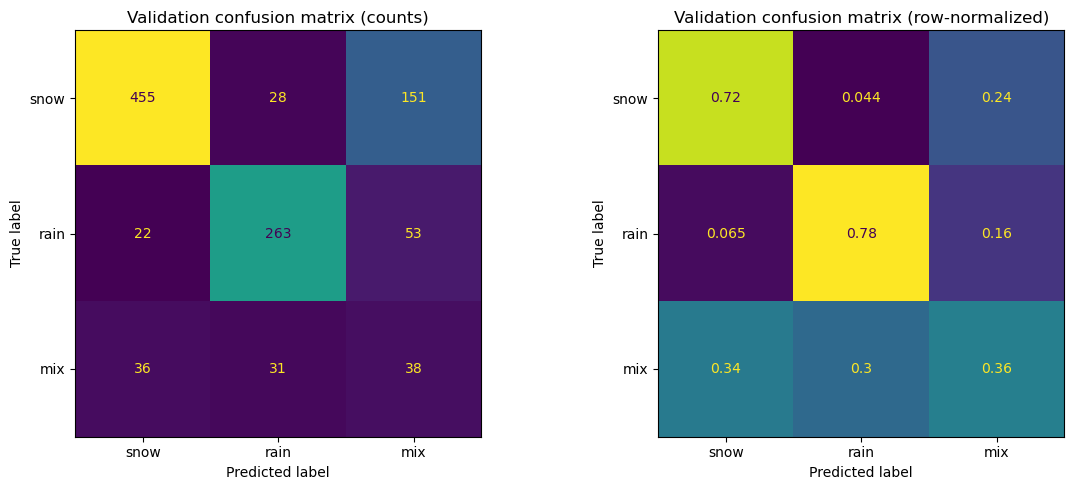


=== ONE-vs-REST BRIER SCORES ===
 snow: 0.1430
 rain: 0.0861
  mix: 0.1296


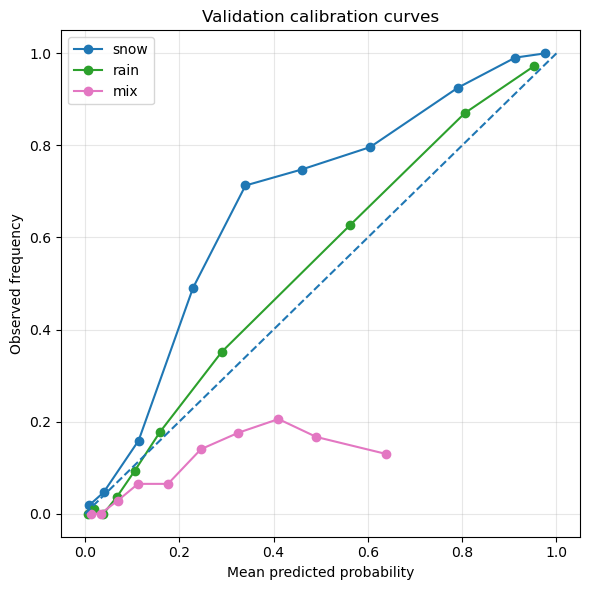

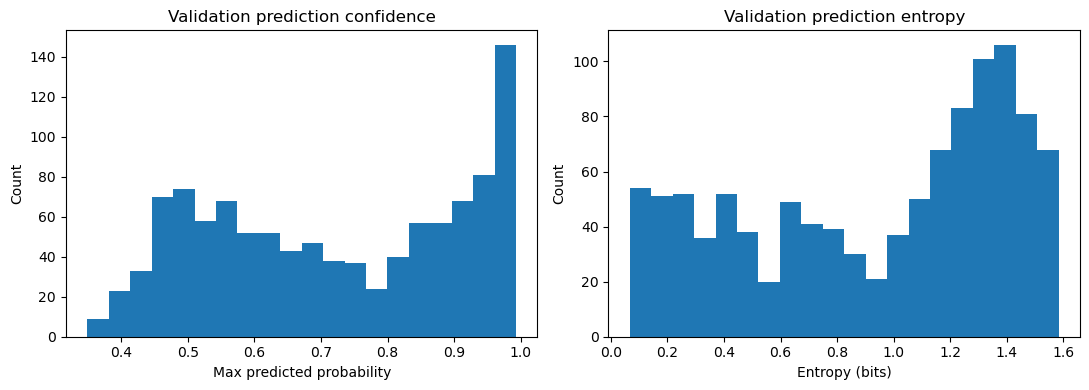


=== Near-freezing air temp: |temp_air| <= 1C ===
Samples: 182
Accuracy:           0.7912
Balanced accuracy:  0.4203
Macro F1:           0.4113
Multiclass logloss: 0.4760
Class counts: {0: 153, 1: 15, 2: 14}
              precision    recall  f1-score   support

        snow      0.880     0.908     0.894       153
        rain      0.500     0.067     0.118        15
         mix      0.182     0.286     0.222        14

    accuracy                          0.791       182
   macro avg      0.521     0.420     0.411       182
weighted avg      0.795     0.791     0.778       182


=== Near-freezing air temp: |temp_air| <= 2C ===
Samples: 369
Accuracy:           0.7371
Balanced accuracy:  0.4833
Macro F1:           0.4654
Multiclass logloss: 0.5259
Class counts: {0: 311, 1: 31, 2: 27}
              precision    recall  f1-score   support

        snow      0.910     0.817     0.861       311
        rain      0.583     0.226     0.326        31
         mix      0.141     0.407     0.

c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


,bin,n,accuracy,balanced_accuracy,macro_f1,mix_recall,predicted_mix_fraction
0,"(-inf, -2.0]",52,0.980769,0.500000,0.495146,0.000000,0.000000
1,"(-2.0, -1.0]",42,1.000000,1.000000,1.000000,0.000000,0.000000
2,"(-1.0, 0.0]",73,0.917808,0.333333,0.321343,0.000000,0.013699
3,"(0.0, 1.0]",109,0.706422,0.451027,0.409625,0.444444,0.192661
4,"(1.0, 2.0]",145,0.593103,0.514257,0.471052,0.538462,0.386207
5,"(2.0, inf]",656,0.660061,0.578665,0.571560,0.350649,0.250000



=== METRICS BY WET-BULB TEMP BIN ===


,bin,n,accuracy,balanced_accuracy,macro_f1,mix_recall,predicted_mix_fraction
0,"(-inf, -2.0]",244,0.909836,0.552350,0.565957,0.272727,0.057377
1,"(-2.0, -1.0]",170,0.670588,0.543572,0.529522,0.437500,0.282353
2,"(-1.0, 0.0]",243,0.547325,0.476561,0.474328,0.363636,0.341564
3,"(0.0, 1.0]",215,0.581395,0.506884,0.507602,0.300000,0.302326
4,"(1.0, 2.0]",107,0.794393,0.611688,0.609280,0.500000,0.186916
5,"(2.0, inf]",98,0.785714,0.449789,0.381462,0.400000,0.122449


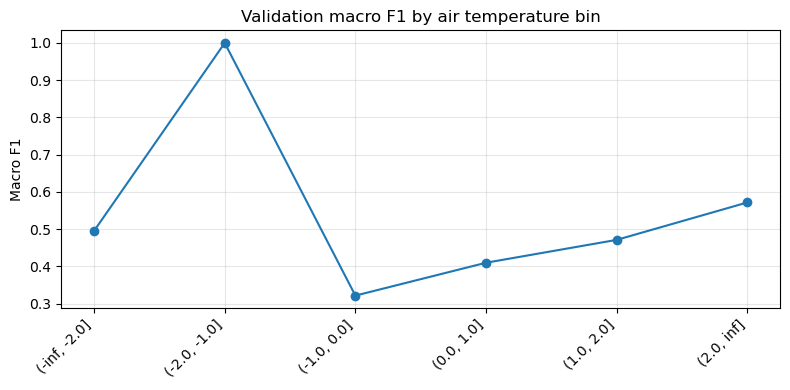

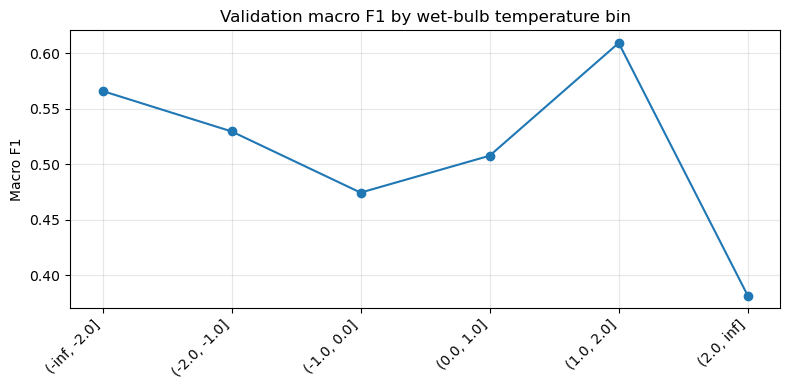

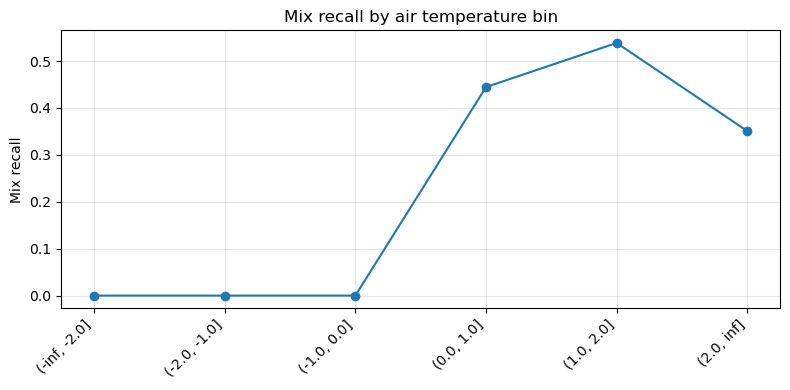

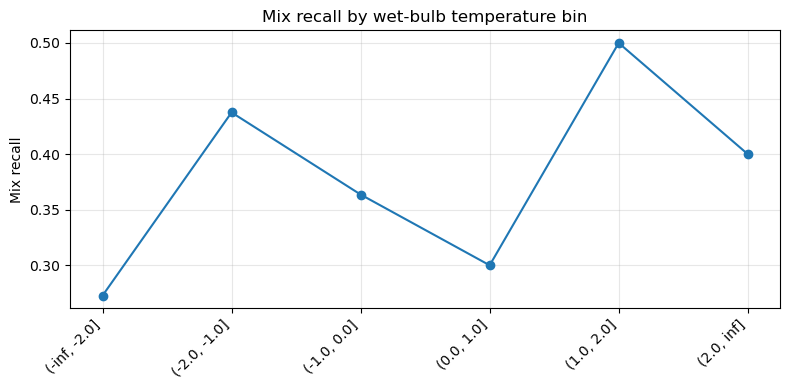

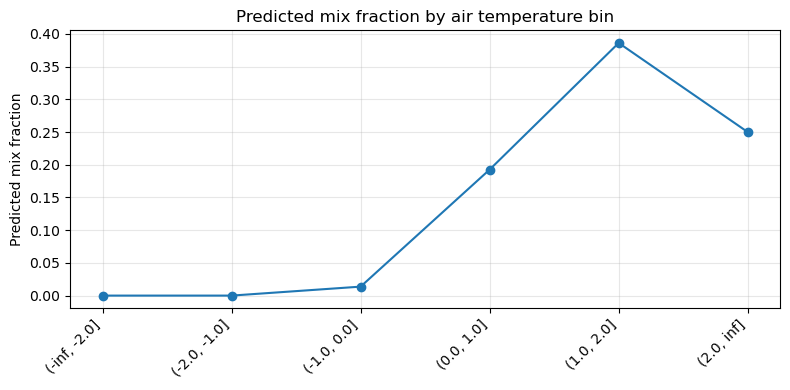

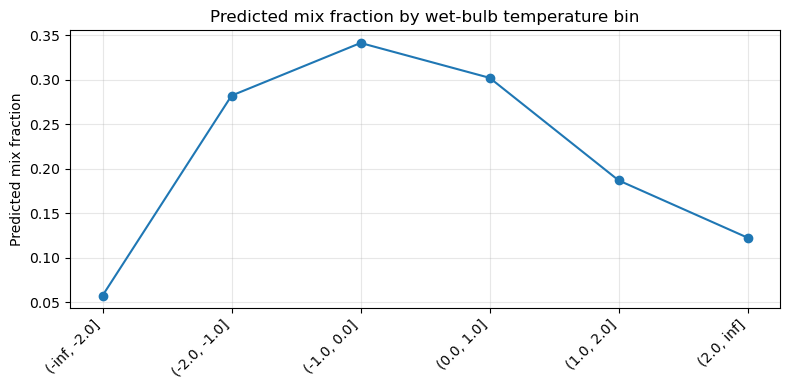

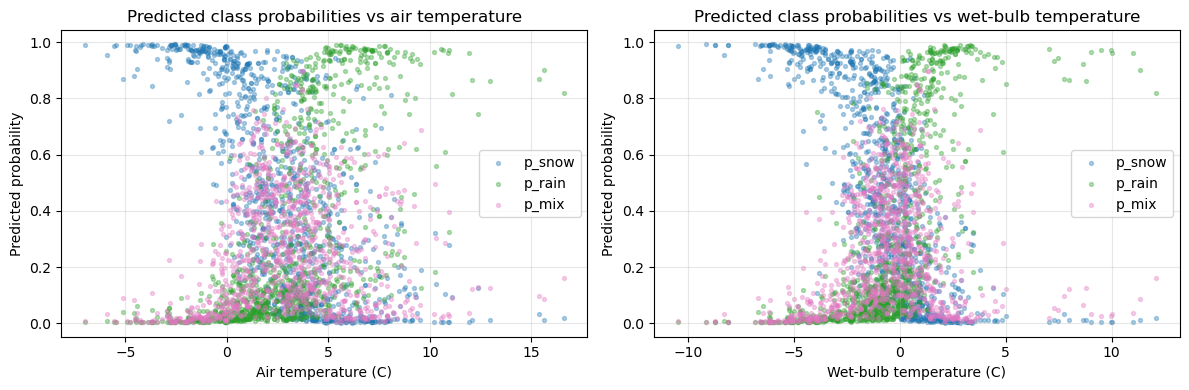

In [35]:
# =============================================================================
# VALIDATION METRICS / VISUALS
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
import seaborn as sns

PHASE_COLORS = {
    "snow": "#1f77b4",   # blue
    "rain": "#2ca02c",   # green
    "mix":  "#e377c2"    # pink
}

CLASS_NAMES = ["snow", "rain", "mix"]
CLASS_CODES = [0, 1, 2]

# ---------------------------------------------------------------------
# Standardize inputs
# ---------------------------------------------------------------------
y_val_true = np.asarray(y_val)
y_val_pred = np.asarray(y_val_pred)
y_val_prob = np.asarray(y_val_prob)

# Pull temp columns from df_val so plots/metrics stay tied to saved outputs
tair = df_val["temp_air"].to_numpy()
twet = df_val["temp_wet"].to_numpy()

# Convenience probability columns
p_snow = y_val_prob[:, 0]
p_rain = y_val_prob[:, 1]
p_mix  = y_val_prob[:, 2]
max_prob = y_val_prob.max(axis=1)

# ---------------------------------------------------------------------
# Overall validation metrics
# ---------------------------------------------------------------------
print("\n=== OVERALL VALIDATION METRICS ===")
print(f"Accuracy:           {accuracy_score(y_val_true, y_val_pred):.4f}")
print(f"Balanced accuracy:  {balanced_accuracy_score(y_val_true, y_val_pred):.4f}")
print(f"Macro F1:           {f1_score(y_val_true, y_val_pred, average='macro'):.4f}")
print(f"Weighted F1:        {f1_score(y_val_true, y_val_pred, average='weighted'):.4f}")
print(f"Multiclass logloss: {log_loss(y_val_true, y_val_prob, labels=CLASS_CODES):.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        labels=CLASS_CODES,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

# ---------------------------------------------------------------------
# Confusion matrices
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_counts = confusion_matrix(y_val_true, y_val_pred, labels=CLASS_CODES)
disp_counts = ConfusionMatrixDisplay(
    confusion_matrix=cm_counts,
    display_labels=CLASS_NAMES,
)
disp_counts.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Validation confusion matrix (counts)")

cm_norm = confusion_matrix(y_val_true, y_val_pred, labels=CLASS_CODES, normalize="true")
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=CLASS_NAMES,
)
disp_norm.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Validation confusion matrix (row-normalized)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# One-vs-rest Brier scores
# ---------------------------------------------------------------------
print("\n=== ONE-vs-REST BRIER SCORES ===")
for i, cname in enumerate(CLASS_NAMES):
    y_bin = (y_val_true == i).astype(int)
    bs = brier_score_loss(y_bin, y_val_prob[:, i])
    print(f"{cname:>5}: {bs:.4f}")

# ---------------------------------------------------------------------
# Calibration curves
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))

for i, cname in enumerate(CLASS_NAMES):
    y_bin = (y_val_true == i).astype(int)
    frac_pos, mean_pred = calibration_curve(
        y_bin,
        y_val_prob[:, i],
        n_bins=10,
        strategy="quantile"
    )
    ax.plot(mean_pred, frac_pos, marker="o", label=cname, color=PHASE_COLORS[cname])

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Validation calibration curves")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Confidence / uncertainty distributions
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(max_prob, bins=20)
axes[0].set_xlabel("Max predicted probability")
axes[0].set_ylabel("Count")
axes[0].set_title("Validation prediction confidence")

if "entropy" in df_val.columns:
    axes[1].hist(df_val["entropy"], bins=20)
    axes[1].set_xlabel("Entropy (bits)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Validation prediction entropy")
else:
    axes[1].hist(p_mix, bins=20)
    axes[1].set_xlabel("Predicted mix probability")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Validation predicted mix probability")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Near-freezing subset summaries
# ---------------------------------------------------------------------
def summarize_subset(mask, label):
    mask = np.asarray(mask)

    print(f"\n=== {label} ===")
    print(f"Samples: {mask.sum()}")

    if mask.sum() == 0:
        print("No samples in subset.")
        return

    yt = y_val_true[mask]
    yp = y_val_pred[mask]
    yprob = y_val_prob[mask]

    print(f"Accuracy:           {accuracy_score(yt, yp):.4f}")
    print(f"Balanced accuracy:  {balanced_accuracy_score(yt, yp):.4f}")
    print(f"Macro F1:           {f1_score(yt, yp, average='macro'):.4f}")
    print(f"Multiclass logloss: {log_loss(yt, yprob, labels=CLASS_CODES):.4f}")

    print("Class counts:", pd.Series(yt).value_counts().sort_index().to_dict())
    print(
        classification_report(
            yt,
            yp,
            labels=CLASS_CODES,
            target_names=CLASS_NAMES,
            digits=3,
            zero_division=0,
        )
    )

summarize_subset(np.abs(tair) <= 1.0, "Near-freezing air temp: |temp_air| <= 1C")
summarize_subset(np.abs(tair) <= 2.0, "Near-freezing air temp: |temp_air| <= 2C")
summarize_subset(np.abs(twet) <= 1.0, "Near-freezing wet-bulb: |temp_wet| <= 1C")
summarize_subset(np.abs(twet) <= 2.0, "Near-freezing wet-bulb: |temp_wet| <= 2C")

# ---------------------------------------------------------------------
# Metrics by temperature bin
# ---------------------------------------------------------------------
def metrics_by_temp_bin(temp_values, y_true, y_pred, bins, temp_label):
    temp_values = np.asarray(temp_values)

    df_bin = pd.DataFrame({
        temp_label: temp_values,
        "y_true": y_true,
        "y_pred": y_pred,
    })

    df_bin["bin"] = pd.cut(df_bin[temp_label], bins=bins)

    rows = []
    for b, g in df_bin.groupby("bin", observed=False):
        if len(g) == 0:
            continue

        rows.append({
            "bin": str(b),
            "n": len(g),
            "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
            "balanced_accuracy": balanced_accuracy_score(g["y_true"], g["y_pred"]),
            "macro_f1": f1_score(g["y_true"], g["y_pred"], average="macro"),
            "mix_recall": (
                ((g["y_true"] == 2) & (g["y_pred"] == 2)).sum() / max((g["y_true"] == 2).sum(), 1)
            ),
            "predicted_mix_fraction": (g["y_pred"] == 2).mean(),
        })

    return pd.DataFrame(rows)

TEMP_BINS = [-np.inf, -2, -1, 0, 1, 2, np.inf]

air_bin_metrics = metrics_by_temp_bin(
    tair, y_val_true, y_val_pred, TEMP_BINS, "temp_air"
)
wet_bin_metrics = metrics_by_temp_bin(
    twet, y_val_true, y_val_pred, TEMP_BINS, "temp_wet"
)

print("\n=== METRICS BY AIR TEMP BIN ===")
display(air_bin_metrics)

print("\n=== METRICS BY WET-BULB TEMP BIN ===")
display(wet_bin_metrics)

# ---------------------------------------------------------------------
# Plots: macro F1 by temperature bin
# ---------------------------------------------------------------------
for df_plot, title in [
    (air_bin_metrics, "Validation macro F1 by air temperature bin"),
    (wet_bin_metrics, "Validation macro F1 by wet-bulb temperature bin"),
]:
    plt.figure(figsize=(8, 4))
    plt.plot(df_plot["bin"], df_plot["macro_f1"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Macro F1")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# Plots: mix behavior by temperature bin
# ---------------------------------------------------------------------
for df_plot, title, ycol, ylabel in [
    (air_bin_metrics, "Mix recall by air temperature bin", "mix_recall", "Mix recall"),
    (wet_bin_metrics, "Mix recall by wet-bulb temperature bin", "mix_recall", "Mix recall"),
    (air_bin_metrics, "Predicted mix fraction by air temperature bin", "predicted_mix_fraction", "Predicted mix fraction"),
    (wet_bin_metrics, "Predicted mix fraction by wet-bulb temperature bin", "predicted_mix_fraction", "Predicted mix fraction"),
]:
    plt.figure(figsize=(8, 4))
    plt.plot(df_plot["bin"], df_plot[ycol], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# Probability vs temperature visuals
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(tair, p_snow, s=8, alpha=0.35, label="p_snow", color=PHASE_COLORS["snow"])
axes[0].scatter(tair, p_rain, s=8, alpha=0.35, label="p_rain", color=PHASE_COLORS["rain"])
axes[0].scatter(tair, p_mix,  s=8, alpha=0.35, label="p_mix", color=PHASE_COLORS["mix"])
axes[0].set_xlabel("Air temperature (C)")
axes[0].set_ylabel("Predicted probability")
axes[0].set_title("Predicted class probabilities vs air temperature")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(twet, p_snow, s=8, alpha=0.35, label="p_snow", color=PHASE_COLORS["snow"])
axes[1].scatter(twet, p_rain, s=8, alpha=0.35, label="p_rain", color=PHASE_COLORS["rain"])
axes[1].scatter(twet, p_mix,  s=8, alpha=0.35, label="p_mix", color=PHASE_COLORS["mix"])
axes[1].set_xlabel("Wet-bulb temperature (C)")
axes[1].set_ylabel("Predicted probability")
axes[1].set_title("Predicted class probabilities vs wet-bulb temperature")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()